# Notebook 3: Exploratory Data Analysis (EDA)

Objectives:

- Understand customer churn behavior
- Analyze numerical and categorical variables
- Generate visual reports
- Save charts for documentation and MLflow artifacts

### Imports

In [3]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 3.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.3 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.3 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 3.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 4.0 MB/s  0:00:02
   -------------------

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

### Create Artifact Folder

In [8]:
os.makedirs("artifacts/eda", exist_ok = True)

### Load Training Dataset

In [9]:
df = pd.read_csv("data/processed/train_data.csv")

print(df.shape)
df.head()

(5625, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),94.55,6078.75,0
1,Male,0,No,No,26,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,1022.50,0
2,Female,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),90.20,6297.65,0
3,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,No,Electronic check,84.30,235.05,0
4,Female,0,Yes,No,49,No,No phone service,DSL,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75,0


### Churn Distribution

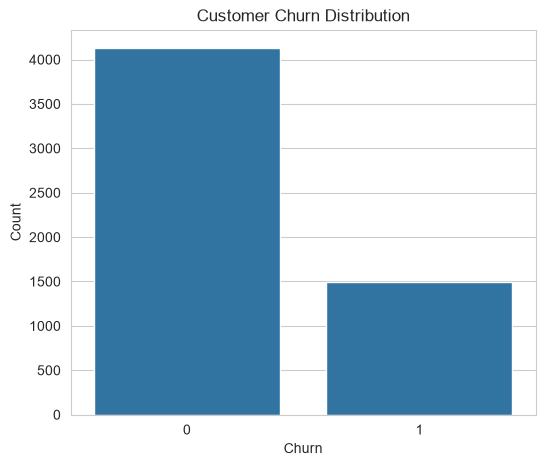

In [10]:
plt.figure(figsize = (6,5))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.savefig(
    "artifacts/eda/churn_distribution.png",
    bbox_inches = "tight"
)

plt.show()

#### Business Insight
- Most customers do not churn.
- Dataset is moderately imbalanced.

### Churn Percentage

In [11]:
(df["Churn"].value_counts(normalize = True) *100).round(2)

Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

###  Numerical Columns

In [12]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='str')


### Correlation Heatmap
Before plotting:

In [13]:
corr_matrix = df[numerical_columns].corr()

#### Then:

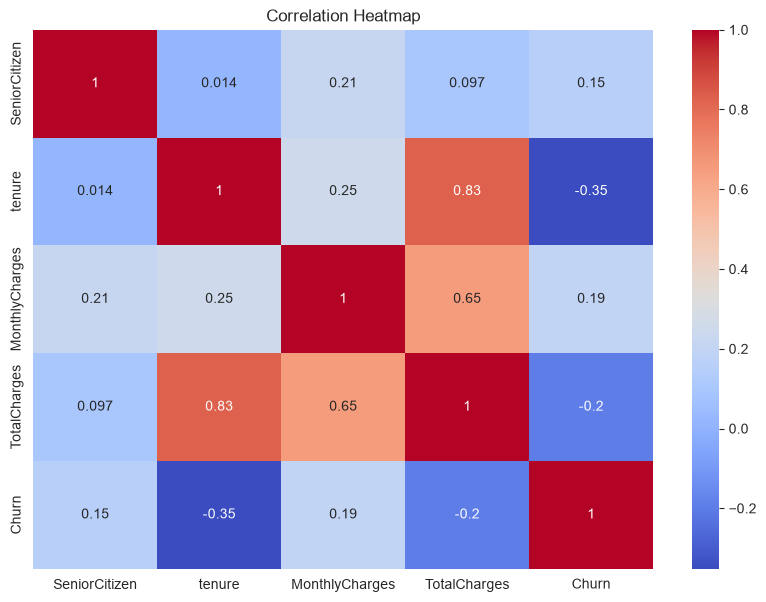

In [14]:
plt.figure(figsize = (10,7))

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "artifacts/eda/correlation_heatmap.png",
    bbox_inches = "tight"
)

plt.show()

### Contract Type vs Churn

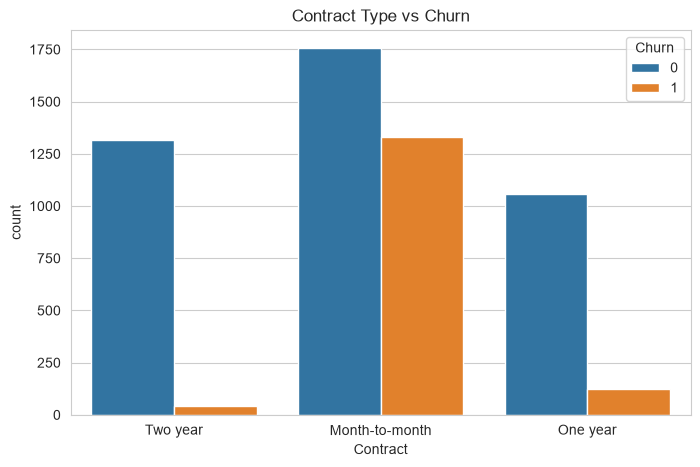

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.savefig(
    "artifacts/eda/contract_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

#### Business Insight
Month-to-month customers generally churn more.

### Monthly Charges Distribution

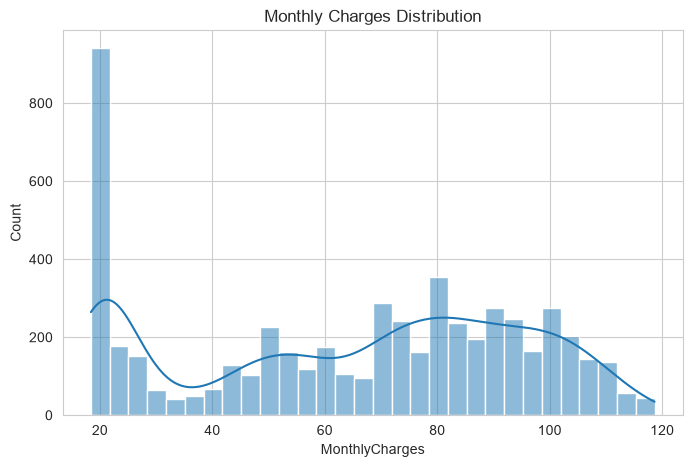

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.savefig(
    "artifacts/eda/monthly_charges_histogram.png",
    bbox_inches="tight"
)

plt.show()

### Monthly Charges vs Churn

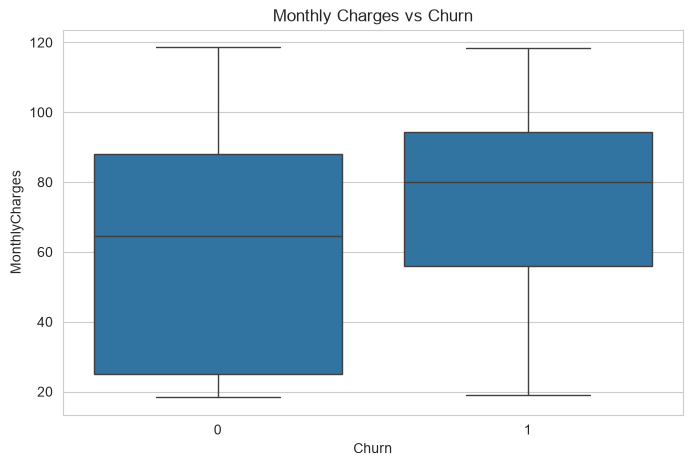

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig(
    "artifacts/eda/monthly_charges_boxplot.png",
    bbox_inches="tight"
)

plt.show()

#### Business Insight
Customers paying higher monthly fees appear more likely to churn.

### Tenure Distribution

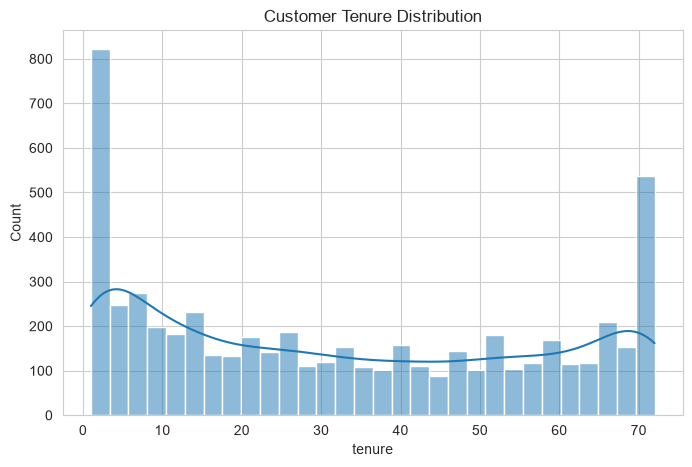

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.savefig(
    "artifacts/eda/tenure_distribution.png",
    bbox_inches="tight"
)

plt.show()

###  Tenure vs Churn

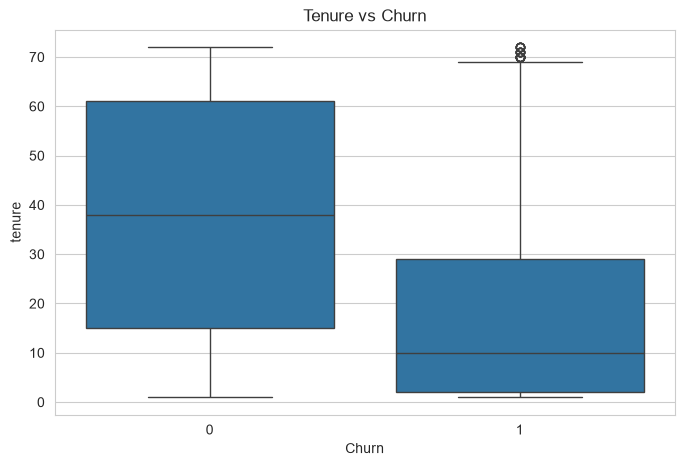

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.savefig(
    "artifacts/eda/tenure_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

#### Business Insight
New customers are more likely to leave.

### Internet Service Distribution

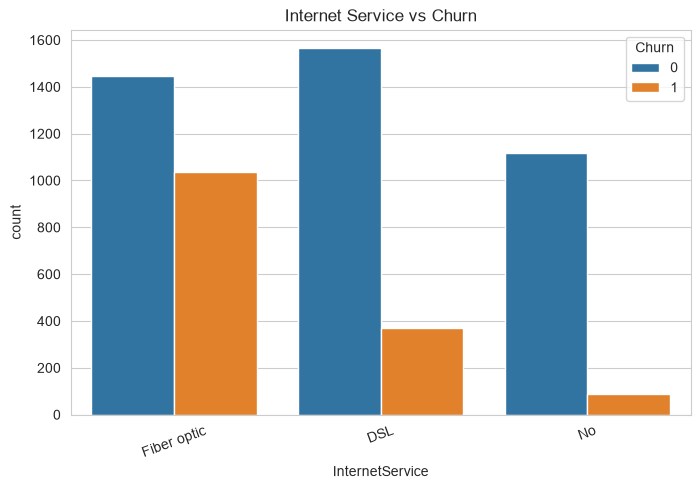

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)

plt.title("Internet Service vs Churn")

plt.savefig(
    "artifacts/eda/internet_service_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

###  Payment Method Analysis

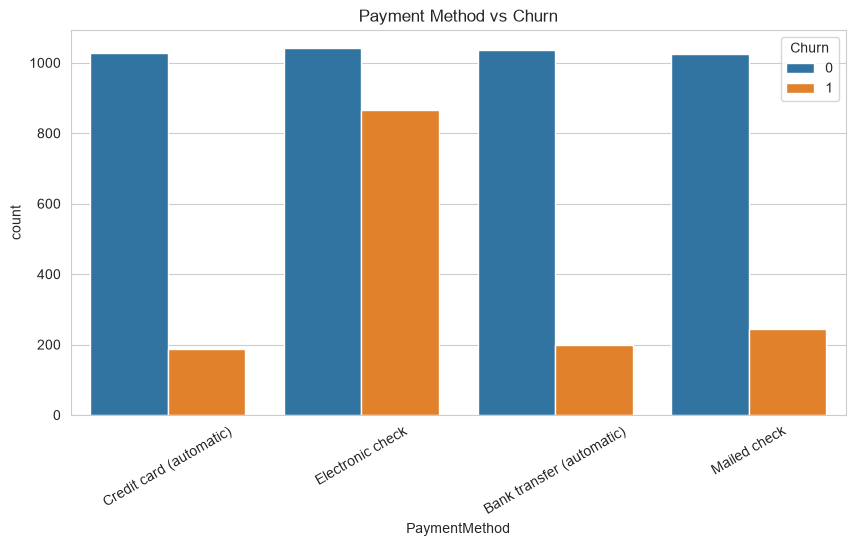

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=30)

plt.title("Payment Method vs Churn")

plt.savefig(
    "artifacts/eda/payment_method_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

### Senior Citizen Analysis

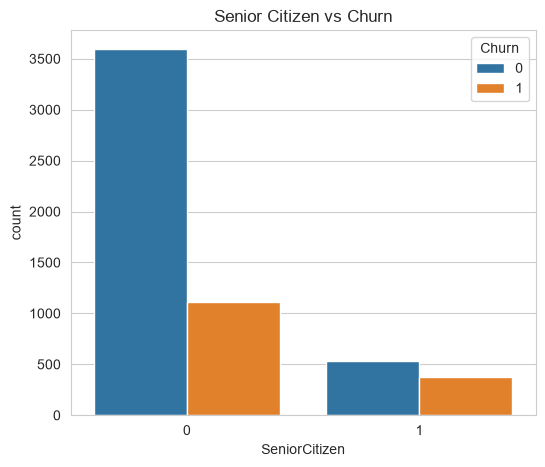

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.savefig(
    "artifacts/eda/senior_citizen_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

### Summary Statistics

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000
mean,0.161778,32.562311,64.999316,2301.839520,0.265778
std,0.368280,24.542421,30.108642,2275.586084,0.441786
min,0.000000,1.000000,18.400000,18.800000,0.000000
25%,0.000000,9.000000,35.800000,413.000000,0.000000
50%,0.000000,29.000000,70.600000,1410.250000,0.000000
75%,0.000000,56.000000,90.050000,3801.700000,1.000000
max,1.000000,72.000000,118.650000,8684.800000,1.000000


### Business Insights

In [26]:
business_insights = [
    "Month-to-month customers have higher churn.",
    "Customers with shorter tenure churn more.",
    "Higher monthly charges are associated with churn.",
    "Certain payment methods show higher churn rates.",
    "Class imbalance exists and should be considered during modeling."
]

business_insights

['Month-to-month customers have higher churn.',
 'Customers with shorter tenure churn more.',
 'Higher monthly charges are associated with churn.',
 'Certain payment methods show higher churn rates.',
 'Class imbalance exists and should be considered during modeling.']

In [27]:
print("Notebook 3 completed successfully.")

Notebook 3 completed successfully.
